# Baseline DQN

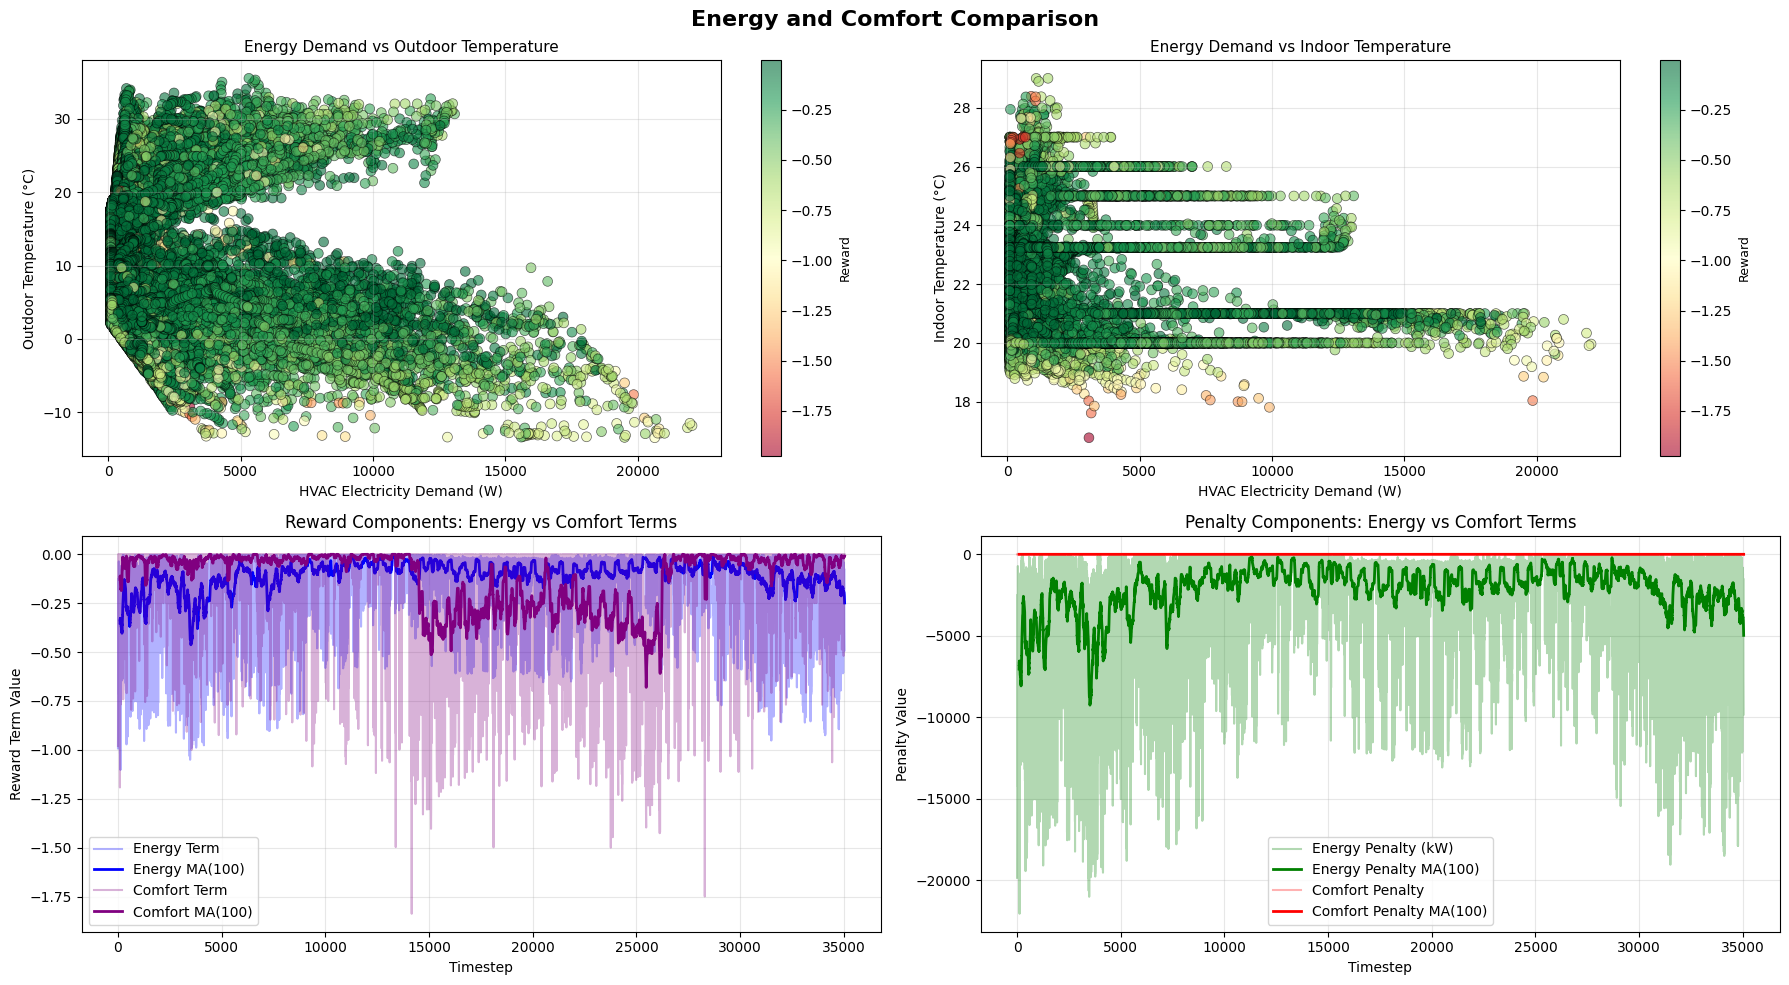

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define paths to the metrics files
base_path = '../outputs/Baseline_Training/DQN_Train-res1/episode-100/monitor'

# Load the CSV data
try:
    reward_data = pd.read_csv(Path(base_path) / 'rewards.csv')
    infos_data = pd.read_csv(Path(base_path) / 'infos.csv')
    obs_data = pd.read_csv(Path(base_path) / 'observations.csv')

    min_len = min(len(obs_data), len(reward_data))
    obs_data = obs_data.iloc[:min_len].reset_index(drop=True)
    reward_data = reward_data.iloc[:min_len].reset_index(drop=True)
except FileNotFoundError:
    print(f"Error: File not found at {base_path}")

# Create observations analysis figure
window = 100
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Energy and Comfort Comparison', fontsize=16, fontweight='bold')

# Plot 1: Energy vs Outdoor Temperature
ax = axes[0, 0]
scatter = ax.scatter(obs_data['HVAC_electricity_demand_rate'], obs_data['outdoor_temperature'], 
                      c=reward_data['reward'], cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('HVAC Electricity Demand (W)', fontsize=10)
ax.set_ylabel('Outdoor Temperature (°C)', fontsize=10)
ax.set_title('Energy Demand vs Outdoor Temperature', fontsize=11)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Reward', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Energy vs Indoor Temperature
ax = axes[0, 1]
scatter = ax.scatter(obs_data['HVAC_electricity_demand_rate'], obs_data['air_temperature'], 
                      c=reward_data['reward'], cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('HVAC Electricity Demand (W)', fontsize=10)
ax.set_ylabel('Indoor Temperature (°C)', fontsize=10)
ax.set_title('Energy Demand vs Indoor Temperature', fontsize=11)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Reward', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Reward Terms
ax = axes[1, 0]
energy_ma = infos_data['energy_term'].rolling(window=window).mean()
comfort_ma = infos_data['comfort_term'].rolling(window=window).mean()

ax.plot(infos_data['energy_term'], alpha=0.3, label='Energy Term', color='blue')
ax.plot(energy_ma, label=f'Energy MA({window})', color='blue', linewidth=2)
ax.plot(infos_data['comfort_term'], alpha=0.3, label='Comfort Term', color='purple')
ax.plot(comfort_ma, label=f'Comfort MA({window})', color='purple', linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Reward Term Value')
ax.set_title('Reward Components: Energy vs Comfort Terms')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Penalty terms
ax = axes[1, 1]
energy_ma = infos_data['energy_penalty'].rolling(window=window).mean()
comfort_ma = infos_data['comfort_penalty'].rolling(window=window).mean()

ax.plot(infos_data['energy_penalty'], alpha=0.3, label='Energy Penalty (kW)', color='green')
ax.plot(energy_ma, label=f'Energy Penalty MA({window})', color='green', linewidth=2)
ax.plot(infos_data['comfort_penalty'], alpha=0.3, label='Comfort Penalty', color='red')
ax.plot(comfort_ma, label=f'Comfort Penalty MA({window})', color='red', linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Penalty Value')
ax.set_title('Penalty Components: Energy vs Comfort Terms')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# DQN vs. DQN-LSTM

Loaded Baseline metrics from ../outputs/Baseline_Training/DQN_Train-res1/evaluation/evaluation_metrics.csv
Loaded DQN metrics from ../outputs/DQN_Training-1.0/DQN_Train-res1/evaluation/evaluation_metrics.csv


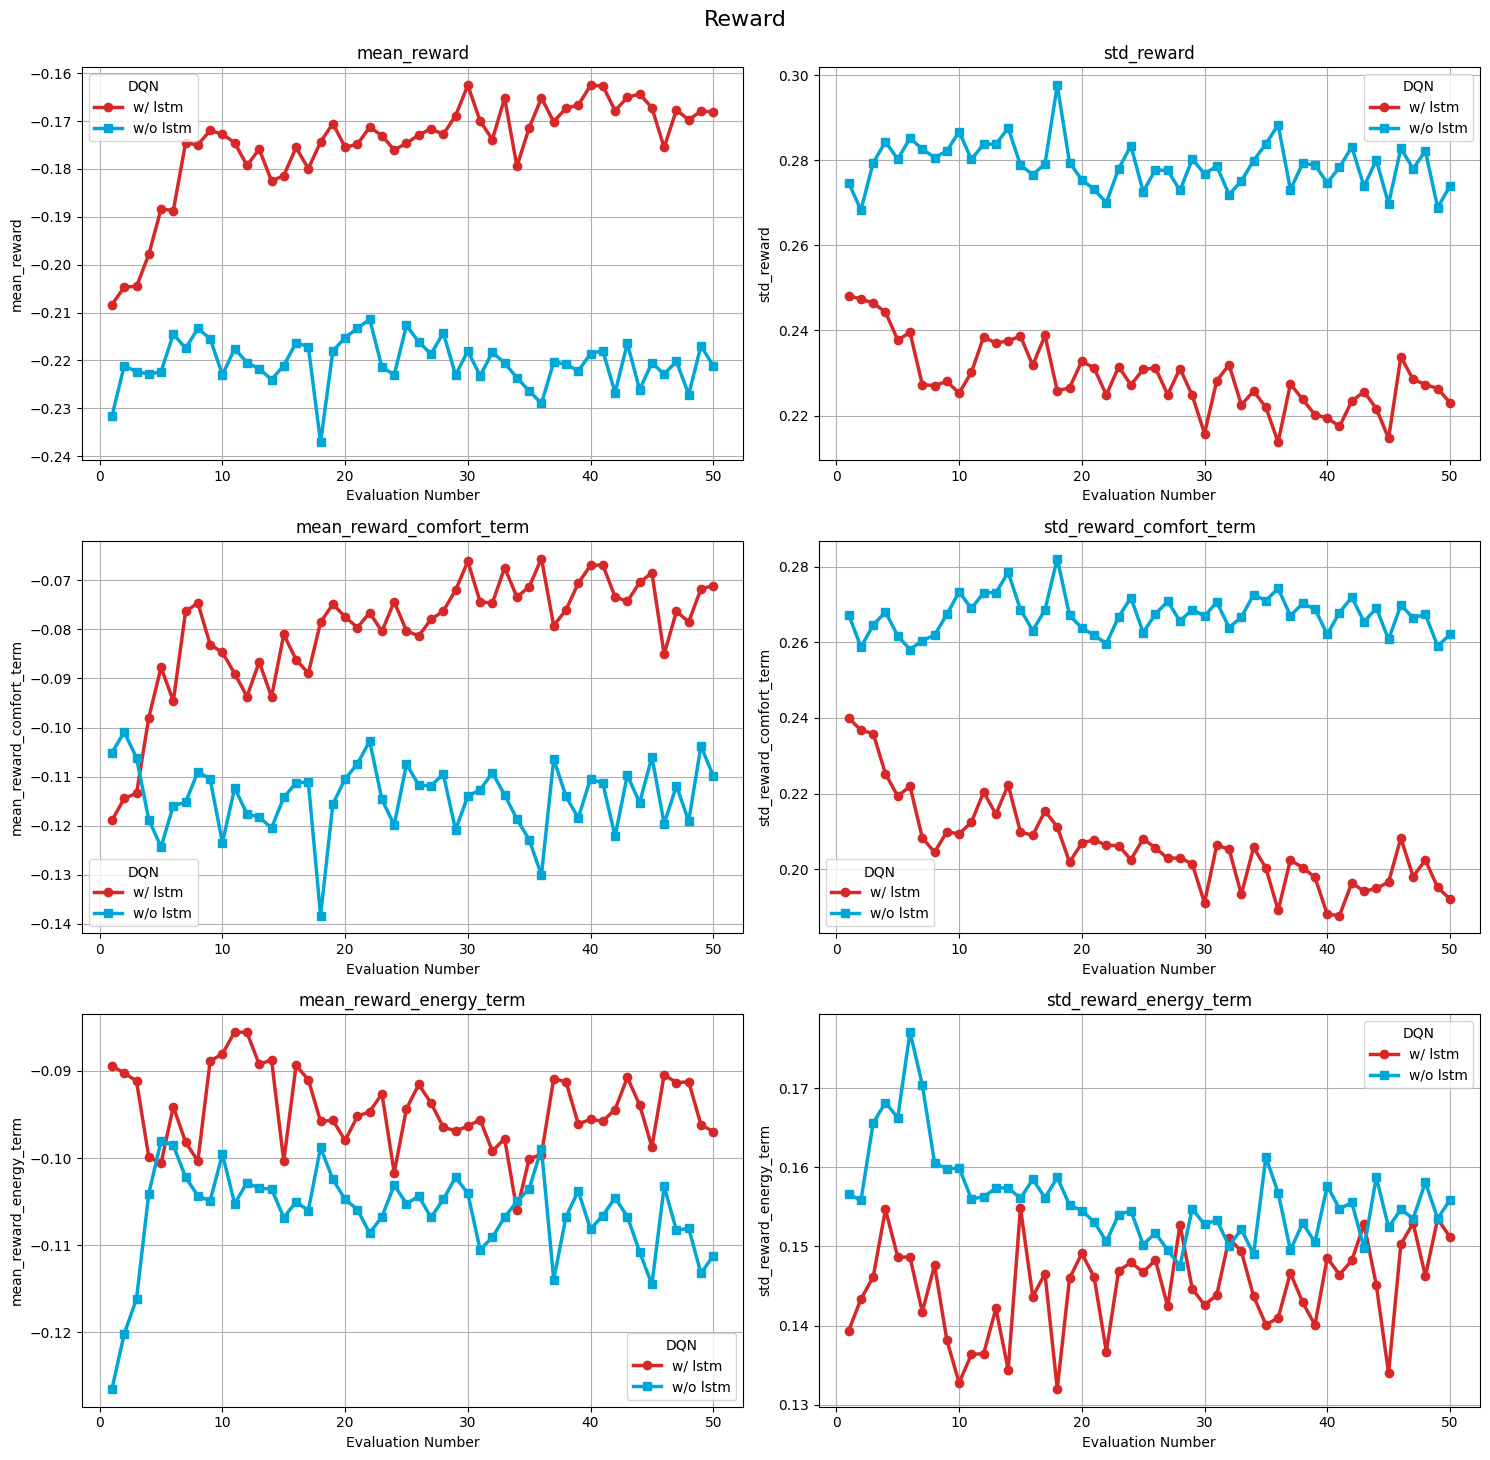

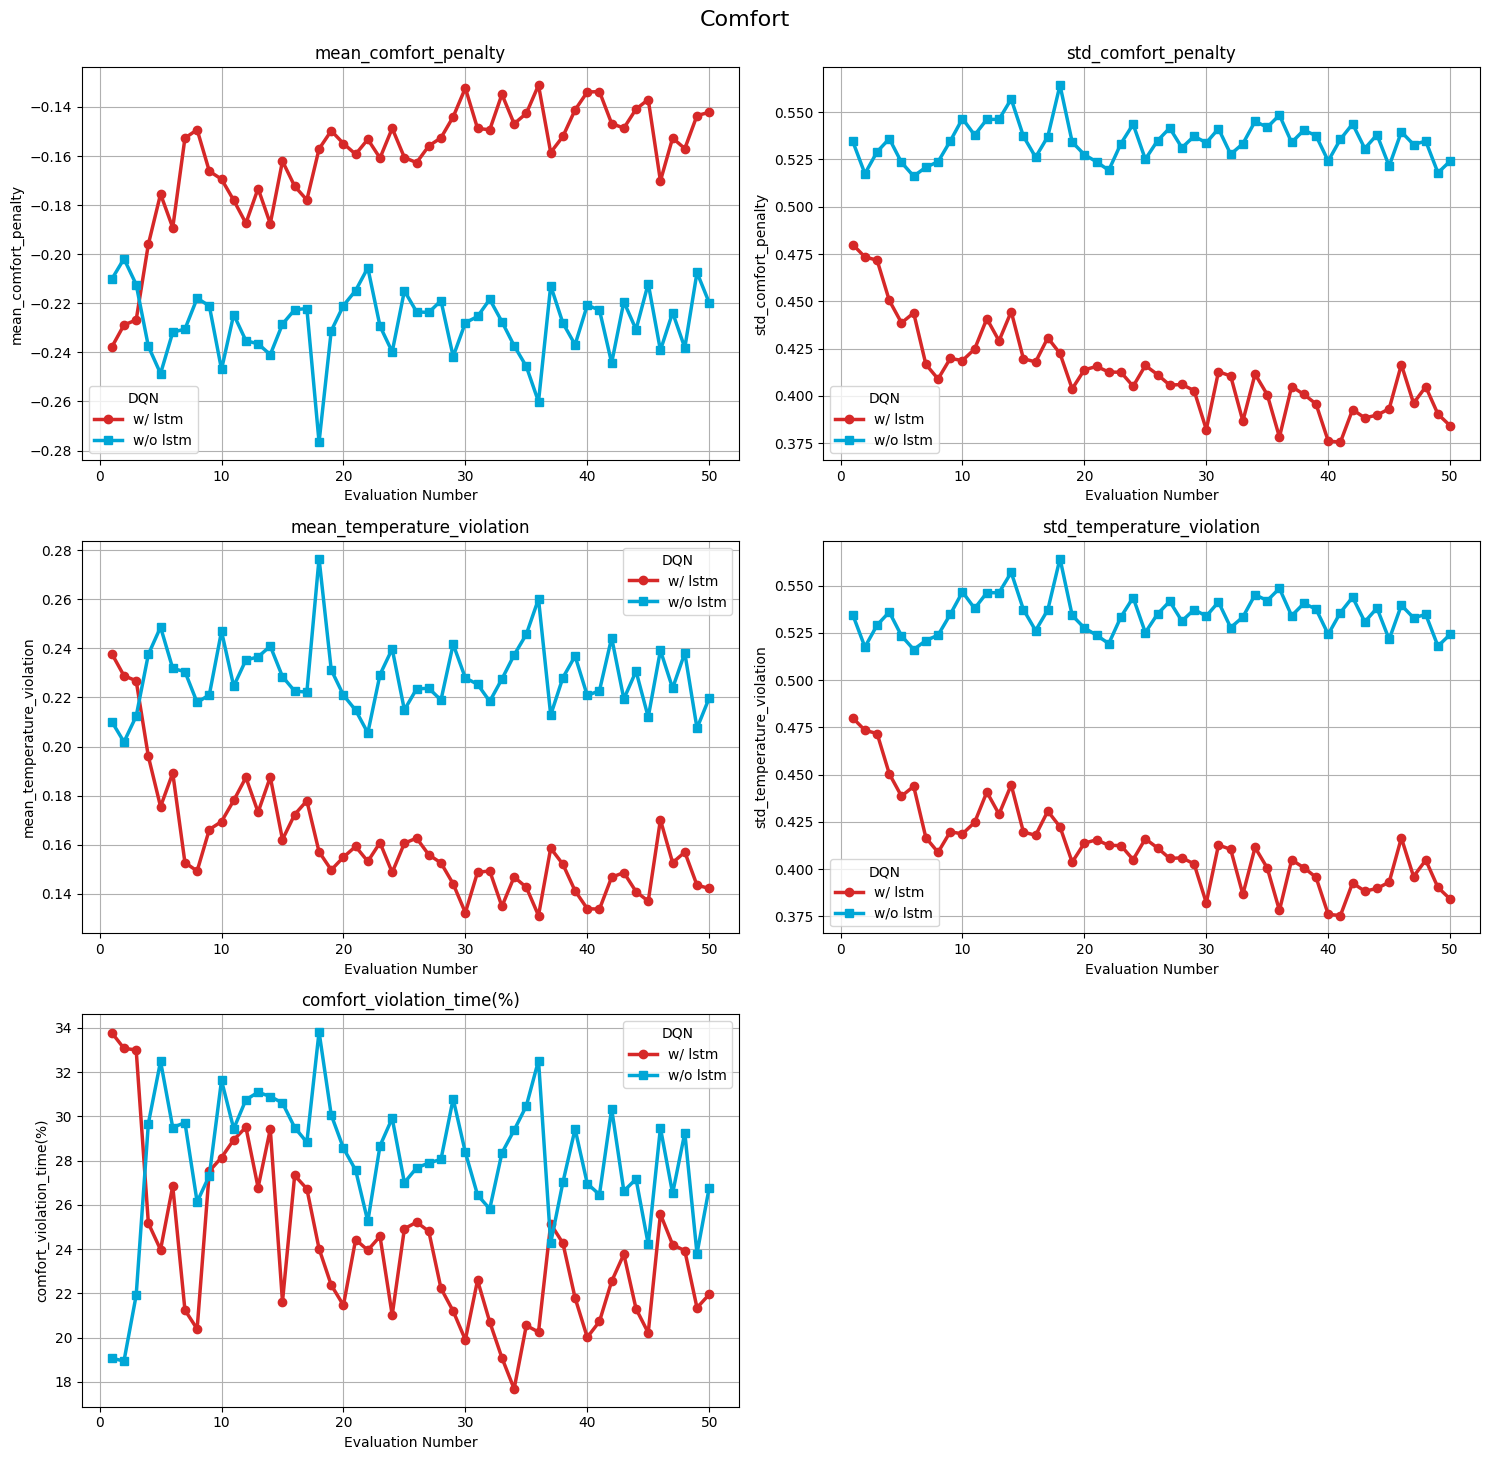

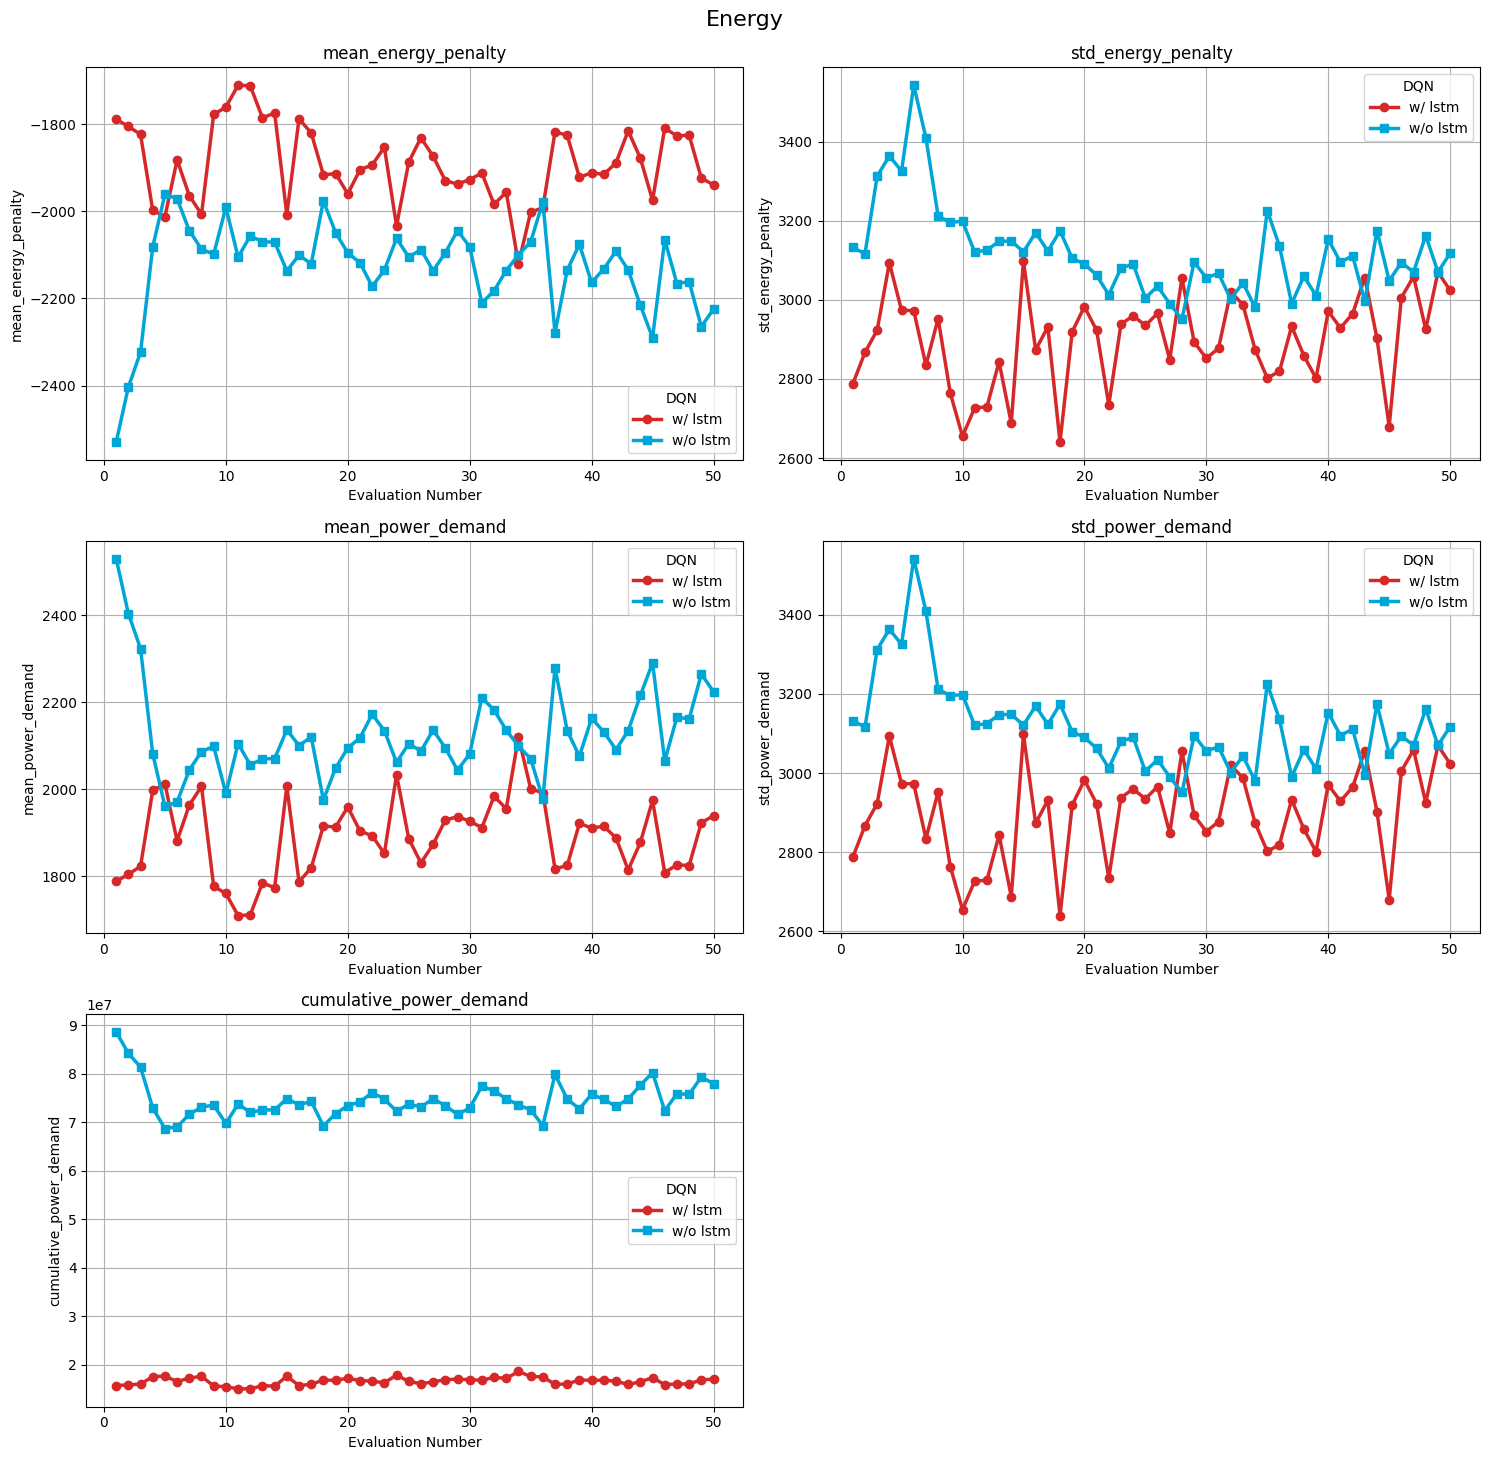

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define paths to the metrics files
baseline_path = '../outputs/Baseline_Training/DQN_Train-res1/evaluation/evaluation_metrics.csv'
dqn_path = '../outputs/DQN_Training-1.0/DQN_Train-res1/evaluation/evaluation_metrics.csv'

# Load the CSV data
try:
    obs_data = pd.read_csv(baseline_path)
    print(f"Loaded Baseline metrics from {baseline_path}")
except FileNotFoundError:
    print(f"Error: Baseline file not found at {baseline_path}")
    obs_data = pd.DataFrame() # Empty

try:
    info_data = pd.read_csv(dqn_path)
    print(f"Loaded DQN metrics from {dqn_path}")
except FileNotFoundError:
    print(f"Error: DQN file not found at {dqn_path}")
    info_data = pd.DataFrame() # Empty

# Define the categories and metrics to plot
categories = {
    "Reward": [
        'mean_reward', 
        'std_reward',
        'mean_reward_comfort_term', 
        'std_reward_comfort_term', 
        'mean_reward_energy_term', 
        'std_reward_energy_term'
    ],
    "Comfort": [
        'mean_comfort_penalty', 
        'std_comfort_penalty', 
        'mean_temperature_violation', 
        'std_temperature_violation', 
        'comfort_violation_time(%)'
    ],
    "Energy": [
        'mean_energy_penalty', 
        'std_energy_penalty', 
        'mean_power_demand', 
        'std_power_demand', 
        'cumulative_power_demand'
    ]
}

# Iterate over categories and create subplots
if not obs_data.empty and not info_data.empty:
    for cat_name, cat_metrics in categories.items():
        n = len(cat_metrics)
        rows = (n + 1) // 2
        cols = 2 if n > 1 else 1
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        fig.suptitle(f"{cat_name}", fontsize=16)
        
        if n > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
        
        for i, metric in enumerate(cat_metrics):
            if i >= len(axes):
                break
            ax = axes[i]
            
            # Determine x-axis
            if 'evaluation_num' in obs_data.columns:
                x_base = obs_data['evaluation_num']
            else:
                x_base = obs_data.index
            
            if 'evaluation_num' in info_data.columns:
                x_dqn = info_data['evaluation_num']
            else:
                x_dqn = info_data.index

            # Check if metric exists in columns
            if metric in info_data.columns:
                ax.plot(x_dqn, info_data[metric], label='w/ lstm', marker='o', linewidth=2.5, markersize=6, color='#D62828')
            if metric in obs_data.columns:
                ax.plot(x_base, obs_data[metric], label='w/o lstm', marker='s', linewidth=2.5, markersize=6, color='#00A6D6')
            
            ax.set_title(metric)
            ax.set_xlabel('Evaluation Number')
            ax.set_ylabel(metric)
            ax.legend(title="DQN")
            ax.grid(True)
            
        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout(rect=[0, 0.01, 1, 0.99])
        plt.show()
else:
    print("Could not plot because one or both dataframes are empty.")

# Sensitivity Analysis

Loaded intensity 0.1 from ../outputs/DQN_Training-0.1/DQN_Train-res1/evaluation/evaluation_metrics.csv
Loaded intensity 1.0 from ../outputs/DQN_Training-1.0/DQN_Train-res1/evaluation/evaluation_metrics.csv
Loaded intensity 2.0 from ../outputs/DQN_Training-2.0/DQN_Train-res1/evaluation/evaluation_metrics.csv
Loaded intensity 3.0 from ../outputs/DQN_Training-3.0/DQN_Train-res1/evaluation/evaluation_metrics.csv
Loaded intensity 5.0 from ../outputs/DQN_Training-5.0/DQN_Train-res1/evaluation/evaluation_metrics.csv
Loaded intensity 7.0 from ../outputs/DQN_Training-7.0/DQN_Train-res1/evaluation/evaluation_metrics.csv


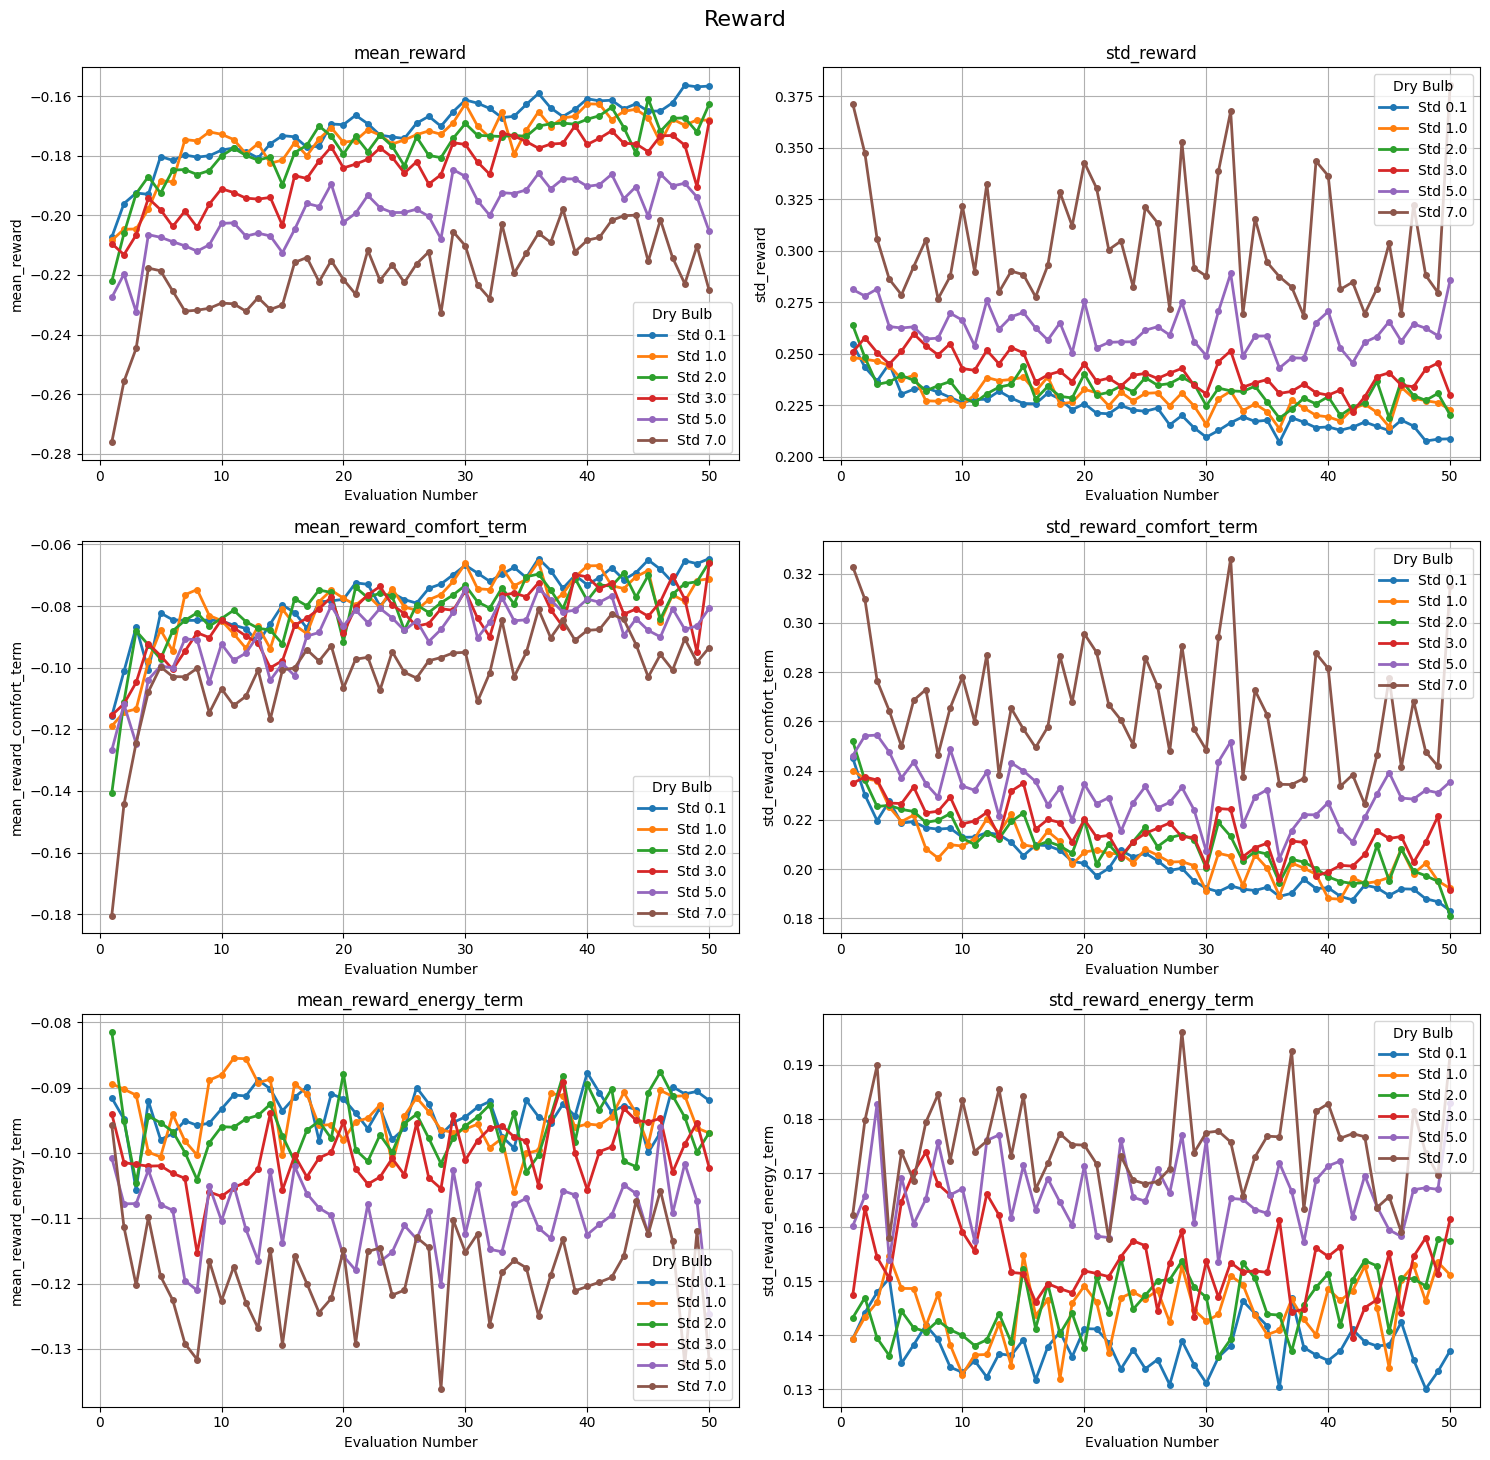

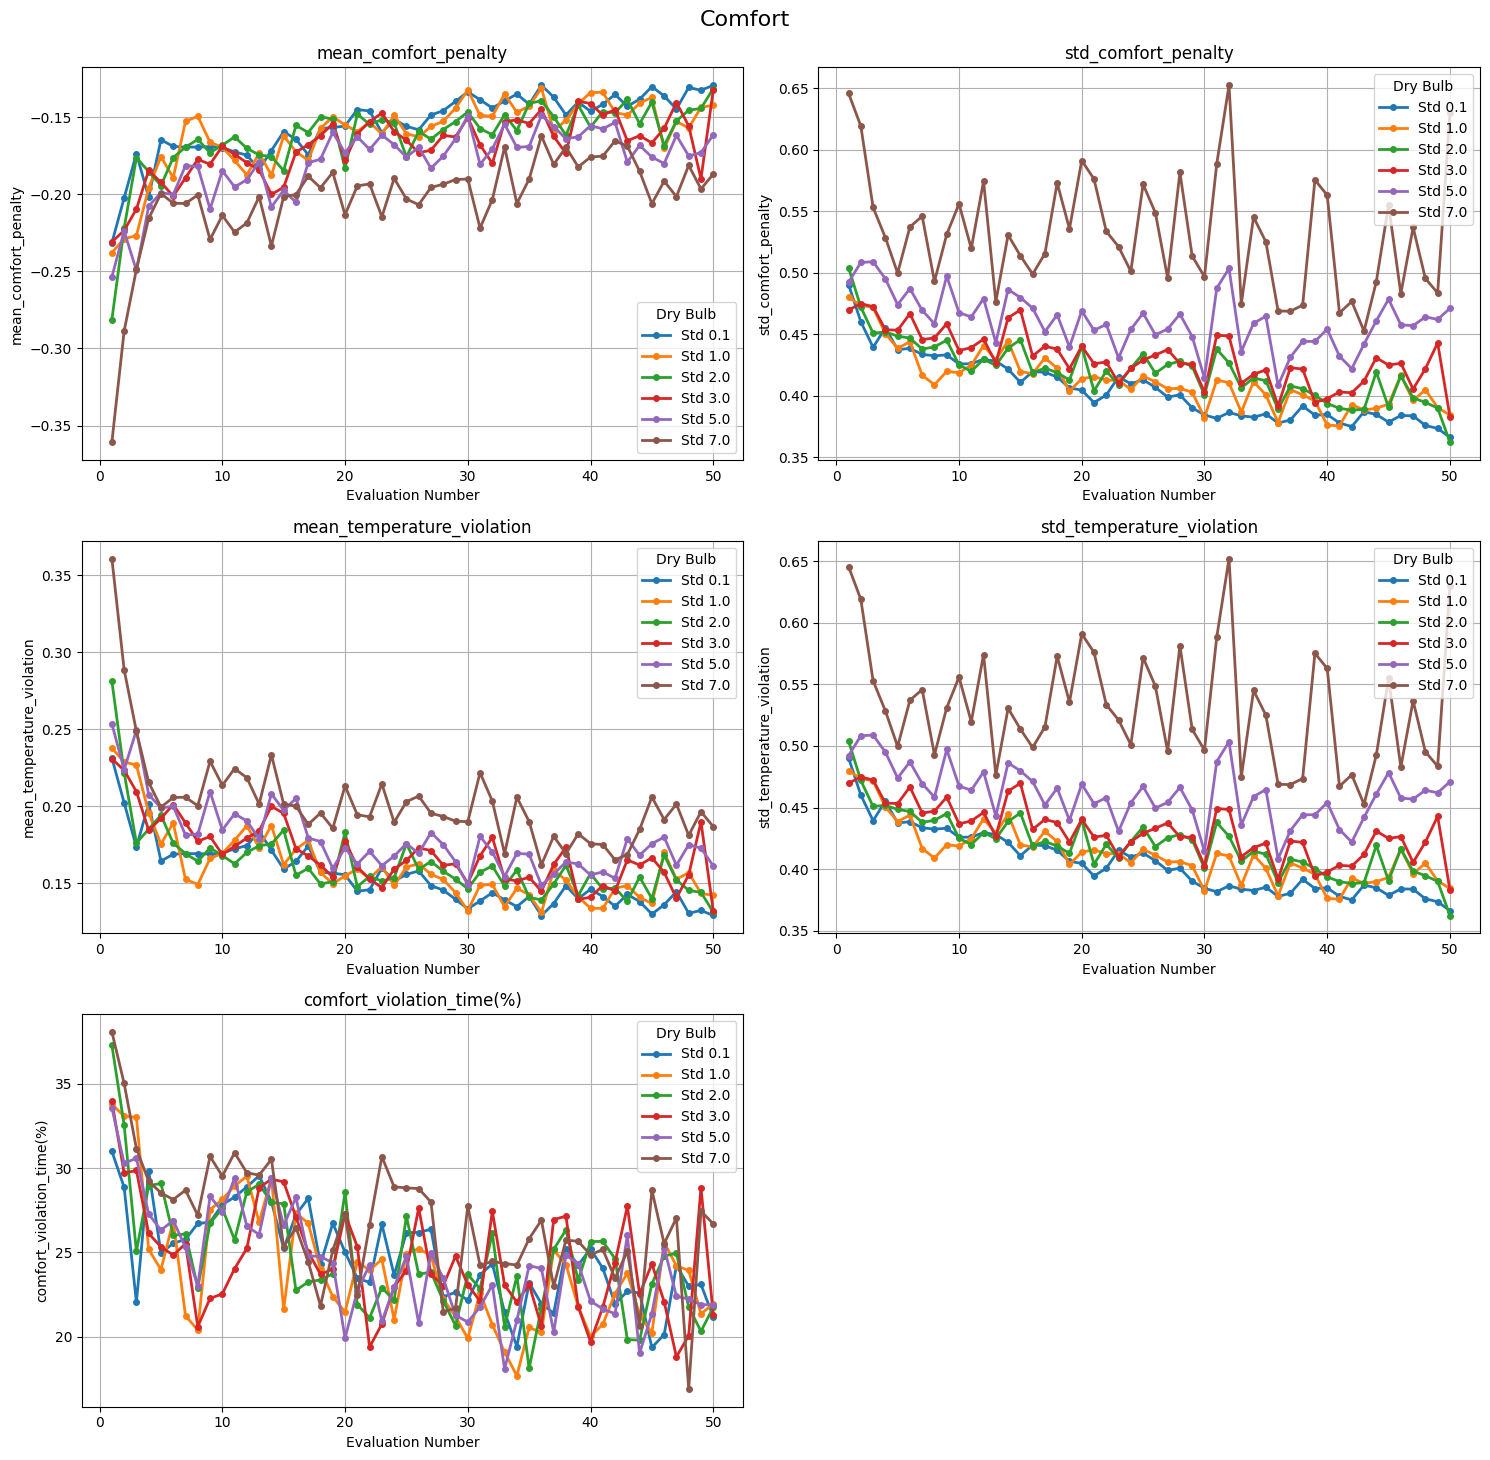

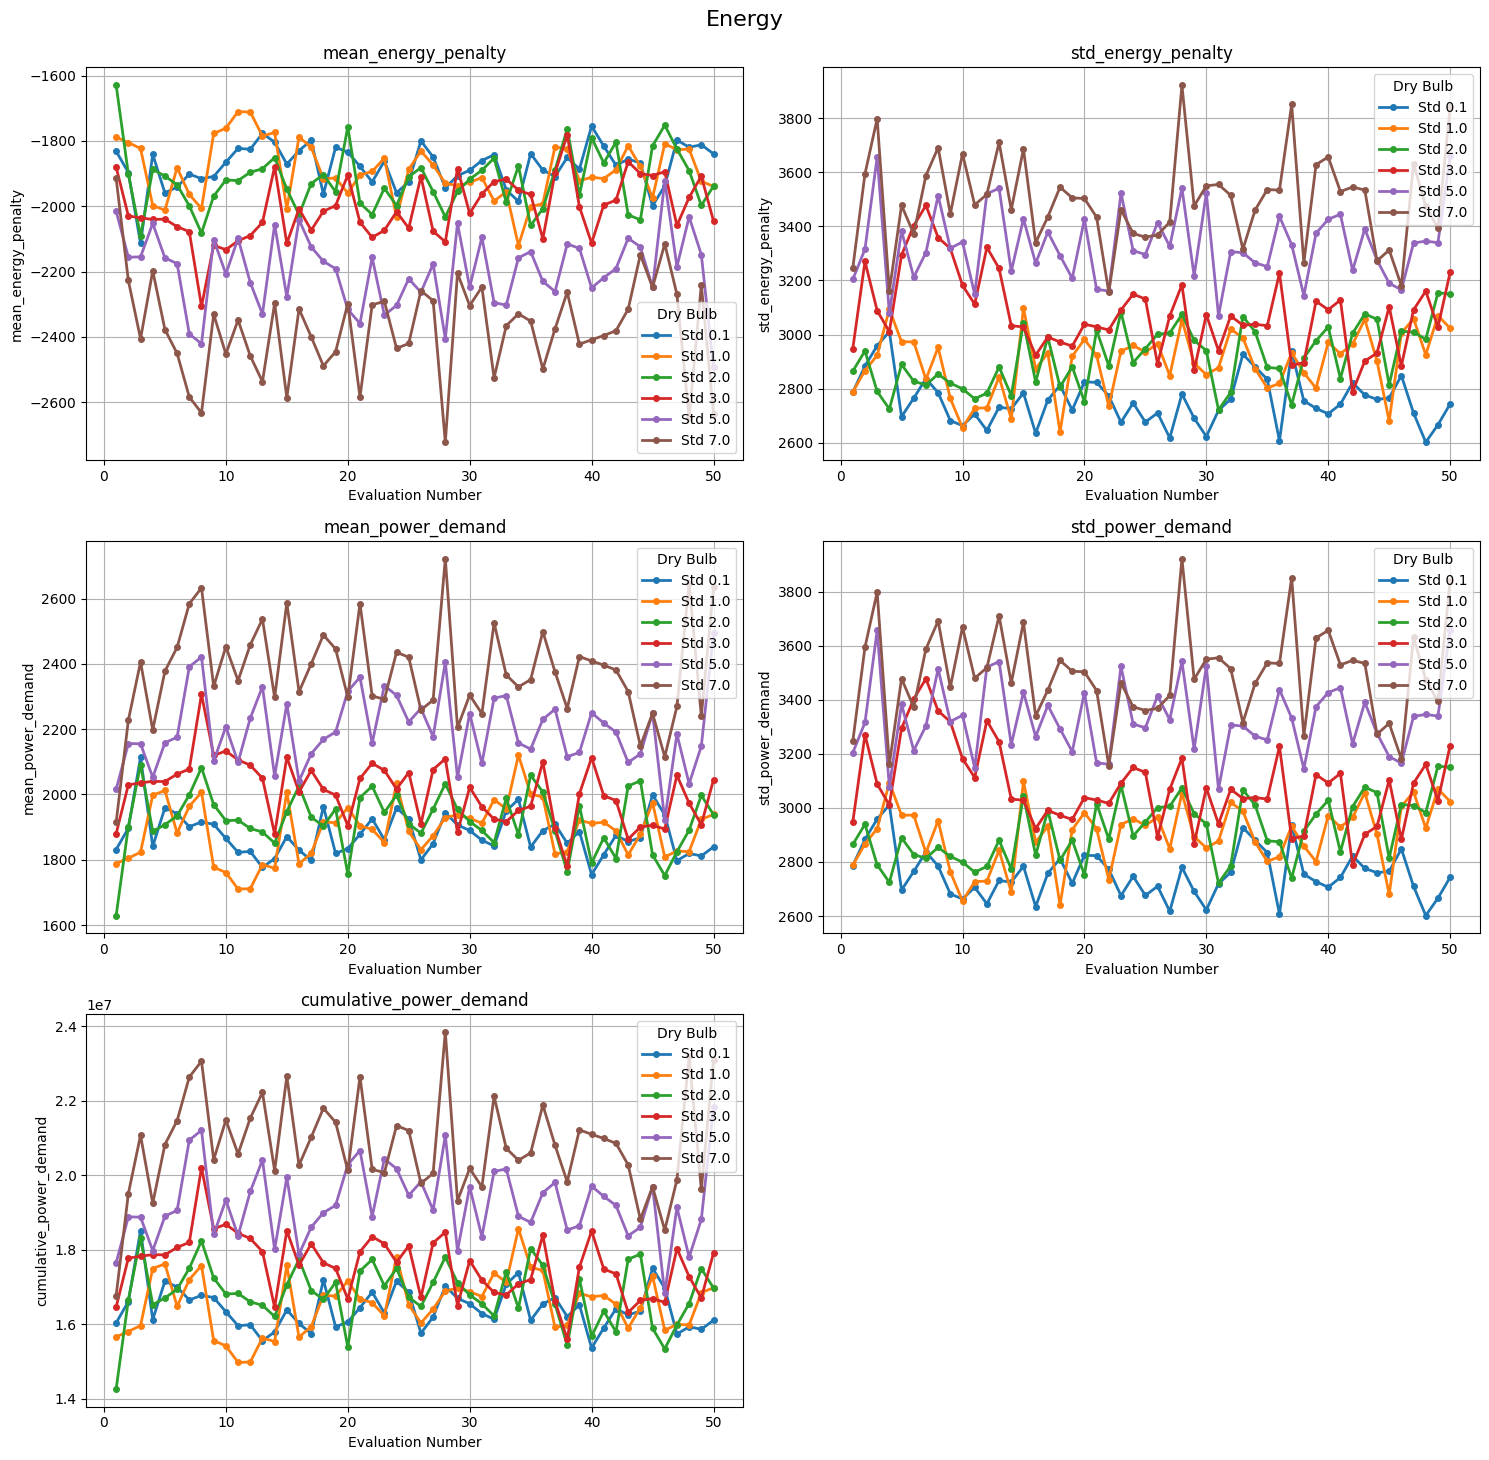

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

# Define paths specifically for DQN intensities comparison
std_noises = ['0.1', '1.0', '2.0', '3.0', '5.0', '7.0']

dfs = {}

for std in std_noises:
    # Construct path assuming standard structure found earlier
    # Note: Using glob to be safe about the 'DQN_Training-X.X' folder name matching exactly
    search_pattern = os.path.join('../outputs', f'DQN_Training-{std}', '*', 'evaluation', 'evaluation_metrics.csv')
    files = glob.glob(search_pattern)
    
    if files:
        # Assuming the first match is the correct one (usually only one per experiment run unless multiple res folders)
        file_path = files[0]
        df = pd.read_csv(file_path)
        dfs[std] = df
        print(f"Loaded intensity {std} from {file_path}")
    else:
        print(f"No metrics file found for intensity {std} with pattern {search_pattern}")


# Define metrics to compare (same categories as above)
categories = {
    "Reward": [
        'mean_reward', 
        'std_reward',
        'mean_reward_comfort_term', 
        'std_reward_comfort_term', 
        'mean_reward_energy_term', 
        'std_reward_energy_term'
    ],
    "Comfort": [
        'mean_comfort_penalty', 
        'std_comfort_penalty', 
        'mean_temperature_violation', 
        'std_temperature_violation', 
        'comfort_violation_time(%)'
    ],
    "Energy": [
        'mean_energy_penalty', 
        'std_energy_penalty', 
        'mean_power_demand', 
        'std_power_demand', 
        'cumulative_power_demand'
    ]
}

if dfs:
    for cat_name, cat_metrics in categories.items():
        n_plots = len(cat_metrics)
        rows = (n_plots + 1) // 2
        cols = 2 if n_plots > 1 else 1
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        fig.suptitle(cat_name, fontsize=16)
        
        if n_plots > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
            
        for i, metric in enumerate(cat_metrics):
            if i >= len(axes):
                break
            ax = axes[i]
            
            # Plot each intensity
            for std in std_noises:
                if std in dfs:
                    df = dfs[std]
                    if metric in df.columns:
                        # Use evaluation number for x-axis if available
                        if 'evaluation_num' in df.columns:
                            x = df['evaluation_num']
                        else:
                            x = df.index
                        
                        ax.plot(x, df[metric], label=f'Std {std}', marker='o', linewidth=2, markersize=4)
            
            ax.set_title(metric)
            ax.set_xlabel('Evaluation Number')
            ax.set_ylabel(metric)
            ax.legend(title="Dry Bulb")
            ax.grid(True)
            
        # Hide empty subplots 
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout(rect=[0, 0.01, 1, 0.99])
        plt.show()
else:
    print("No data loaded to plot.")

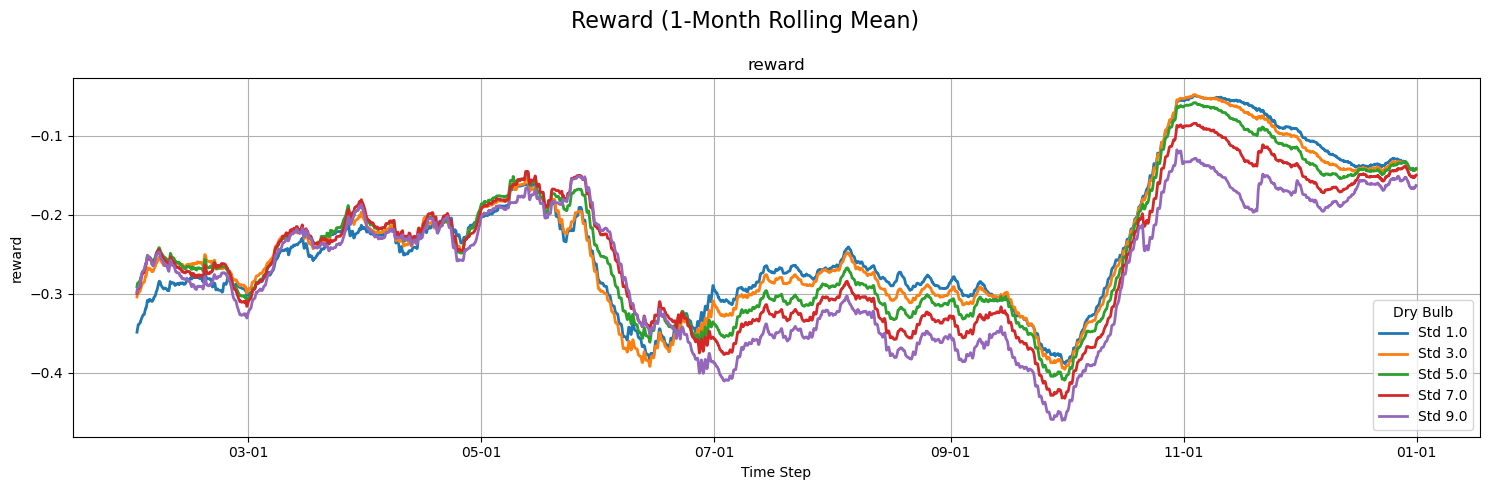

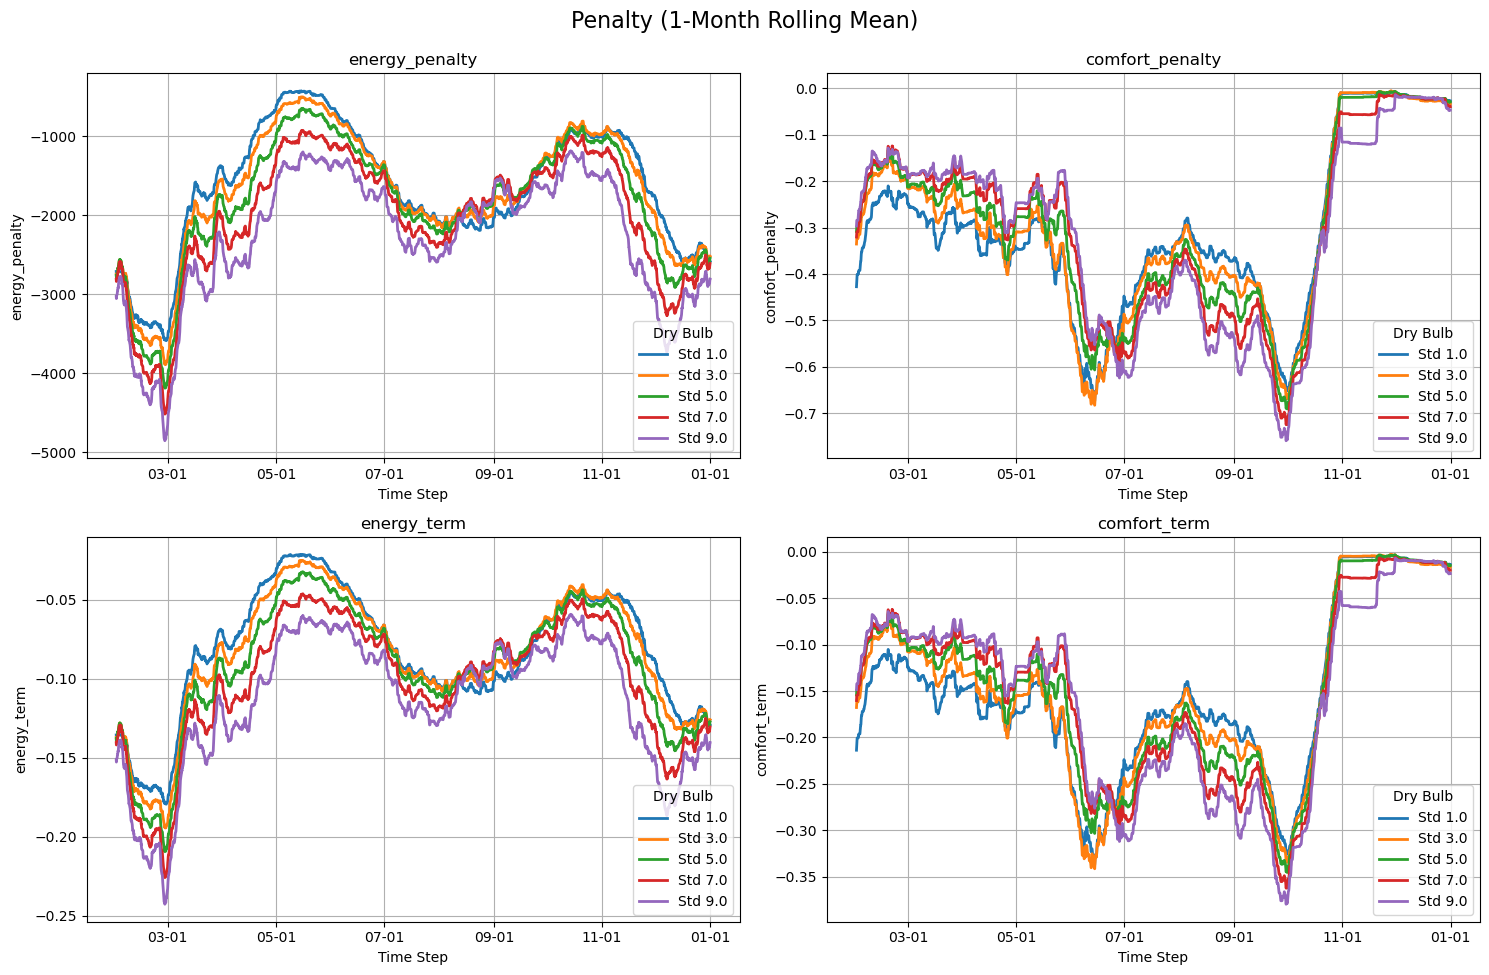

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define paths specifically for DQN intensities comparison
std_noises = ['1.0', '3.0', '5.0', '7.0', '9.0']

dfs = {}

for std in std_noises:
    base_path = f'../outputs/DQN_Noise-{std}-res1/episode-1/monitor'
    rewards = pd.read_csv(f'{base_path}/rewards.csv')
    infos = pd.read_csv(f'{base_path}/infos.csv')

    df = pd.concat([rewards, infos], axis=1).dropna()
    df.index = pd.date_range(start='1991-01-01 00:00:00', periods=len(df), freq='h')
    dfs[std] = df

# Define metrics to compare (same categories as above)
categories = {
    "Reward": [
        'reward'
    ],
    "Penalty": [
        'energy_penalty',
        'comfort_penalty',
        'energy_term',
        'comfort_term'
    ]
}

if dfs:
    for cat_name, cat_metrics in categories.items():
        n_plots = len(cat_metrics)
        rows = (n_plots + 1) // 2
        cols = 2 if n_plots > 1 else 1
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        fig.suptitle(f"{cat_name} (1‑Month Rolling Mean)", fontsize=16)
        
        if n_plots > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
            
        for i, metric in enumerate(cat_metrics):
            if i >= len(axes):
                break
            ax = axes[i]
            
            # Plot each intensity
            for std in std_noises:
                if std in dfs:
                    df = dfs[std]
                    if metric in df.columns:
                        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

                        rolling_metric = df[metric].rolling(window=720).mean()
                        ax.plot(rolling_metric.index, rolling_metric.values, label=f'Std {std}', linewidth=2)

            ax.set_title(metric)
            ax.set_xlabel('Time Step')
            ax.set_ylabel(metric)
            ax.legend(title="Dry Bulb", loc='lower right')
            ax.grid(True)
            
        # Hide empty subplots 
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout(rect=[0, 0.01, 1, 0.99])
        plt.show()
else:
    print("No data loaded to plot.")